# 20260628

In [6]:
import sys
from pathlib import Path
import gzip

import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print(f"Python      : {sys.version.split()[0]}")
print(f"Platform    : {platform.platform()}")

print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"Matplotlib  : {plt.matplotlib.__version__}")

Python      : 3.11.15
Platform    : Linux-6.18.7-76061807-generic-x86_64-with-glibc2.39
NumPy       : 2.4.6
Pandas      : 3.0.3
Matplotlib  : 3.10.9


## FASTQ structure

A FASTQ file stores sequencing reads using four lines per record.

1. Read identifier
2. Nucleotide sequence
3. Separator (`+`)
4. Base quality scores

In [7]:
fastq = Path("../data/1k.fastq.gz")

with gzip.open(fastq, "rt") as f:
    for i in range(8):
        print(f.readline().rstrip())

@e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac runid=d0fb633a8fcd5fbe39934e46437aa38eed37012a ch=2942 start_time=2024-12-10T06:05:47.830848+09:00 flow_cell_id=PBA40360 protocol_group_id=241209-GEBY-1s_AP-P4BBp1439 sample_id=NA03164 barcode=barcode14 barcode_alias=barcode14 parent_read_id=e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac basecall_model_version_id=dna_r10.4.1_e8.2_400bps_hac@v4.3.0
GCTGTTTATGTCATTATTTACTTCGTTCAGTTATGCAGCCAATCCGCAAACTCGCCTACCGTGACAACGAGTCTCTTGGGACCCATAGAACTTGCCTGTCGCTCTCTTCAGAGGAGAATTCCGCCGCCCACAGGTCTTTTTTTTTTTTTTTTTTTTTTAACTAAAAAGGTTTTATTTTATTGAATCATATTTCATTAACGCCACATTACACTCACAAGAACAACGAGAATACAAACAATACAGGCAAGTCTCACGAATCACAACACATCACTTAAACGACCCAAAAAGTTTTTGCAATTTCAGACCCGACCCGACTAACACTATCCCTAAGCTTGACCGGACAATTGTTGATTATCTAGGCGGTGAGCTCATAAGGAGAAGTATCAGTAGCGAGCCATTGCTCCCCAAAACTCCAAGTCCAAGTCTAATTCCAAAGCAATATGAGCACGACGGGATGCGTACCGAGTTGGTG
+
'''(+)&%&'('&&&$$%$$$%''()*.))()'('&$##$##$$$#####%$$%*)((152><<</...2//27564/21333837%%%&$%%%,-,7:74567<,(((*()(*120+**()(+*(*++**'%$%%(*-*,.05667

In [8]:
with gzip.open(fastq, "rt") as f:
    header = f.readline().strip()
    sequence = f.readline().strip()
    plus = f.readline().strip()
    quality = f.readline().strip()

print("Header:")
print(header)

print("\nSequence first 80 nt:")
print(sequence[:80])

print("\nPlus line:")
print(plus)

print("\nQuality first 80 characters:")
print(quality[:80])

print("\nSequence length:", len(sequence))
print("Quality length :", len(quality))

Header:
@e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac runid=d0fb633a8fcd5fbe39934e46437aa38eed37012a ch=2942 start_time=2024-12-10T06:05:47.830848+09:00 flow_cell_id=PBA40360 protocol_group_id=241209-GEBY-1s_AP-P4BBp1439 sample_id=NA03164 barcode=barcode14 barcode_alias=barcode14 parent_read_id=e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac basecall_model_version_id=dna_r10.4.1_e8.2_400bps_hac@v4.3.0

Sequence first 80 nt:
GCTGTTTATGTCATTATTTACTTCGTTCAGTTATGCAGCCAATCCGCAAACTCGCCTACCGTGACAACGAGTCTCTTGGG

Plus line:
+

Quality first 80 characters:
'''(+)&%&'('&&&$$%$$$%''()*.))()'('&$##$##$$$#####%$$%*)((152><<</...2//27564/21

Sequence length: 472
Quality length : 472


In [9]:
read_ids = []
lengths = []

with gzip.open(fastq, "rt") as f:
    while True:
        header = f.readline().strip()
        sequence = f.readline().strip()
        plus = f.readline().strip()
        quality = f.readline().strip()

        if not header:
            break

        assert header.startswith("@")
        assert plus == "+"
        assert len(sequence) == len(quality)

        read_ids.append(header[1:].split()[0])
        lengths.append(len(sequence))

df = pd.DataFrame({
    "read_id": read_ids,
    "length": lengths
})

print(df.shape)
display(df.head())

(1000, 2)


,read_id,length
0,e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac,472
1,976d29dc-8666-41fe-9fdf-8ec7dbd57ee9,529
2,e61fdbfd-bcb3-4c9b-b34b-8e9f6c952c58,471
3,b066f69a-4698-4898-ad43-e1ecb2b4b5ab,489
4,49fa6fba-28a3-4889-b324-880e6e80b971,368


In [10]:
lengths_sorted = sorted(df["length"], reverse=True)

total_bases = sum(lengths_sorted)
half_total_bases = total_bases / 2

running_total = 0
n50 = None

for length in lengths_sorted:
    running_total += length
    
    if running_total >= half_total_bases:
        n50 = length
        break

n50

598

In [14]:
stats = pd.Series({
    "n_reads": len(df),
    "mean_length": df["length"].mean(),
    "stdev_length": df["length"].std(),
    "median_length": df["length"].median(),
    "n50": n50,
    "min_length": df["length"].min(),
    "max_length": df["length"].max(),
})

stats
stats.to_frame(name="Value")

,Value
n_reads,1000.000000
mean_length,600.506000
stdev_length,201.088101
median_length,550.000000
n50,598.000000
min_length,262.000000
max_length,2131.000000


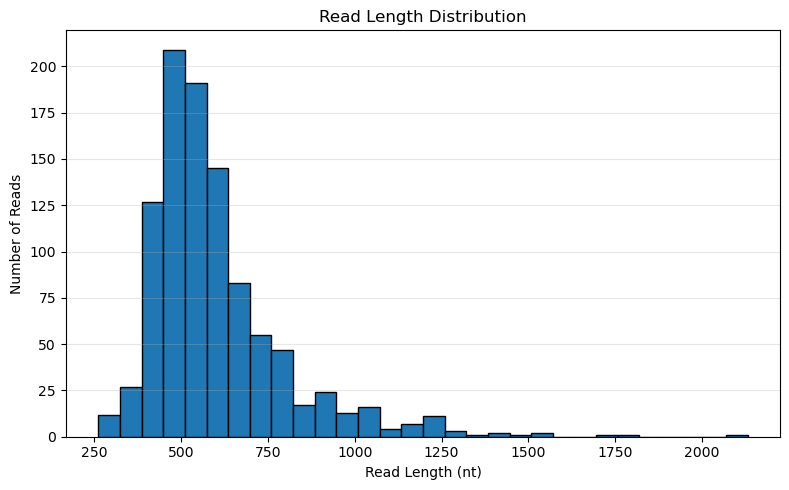

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(df["length"], bins=30, edgecolor="black")

plt.title("Read Length Distribution")
plt.xlabel("Read Length (nt)")
plt.ylabel("Number of Reads")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()